<div style="background: linear-gradient(135deg, #0B1F3F 0%, #008C8C 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: white; font-family: Georgia, serif; margin: 0; font-size: 2.4em;">
🏦 Session 13: Data Cartography
</h1>
<p style="color: #B8953E; font-size: 1.3em; margin-top: 10px; font-family: Calibri, sans-serif;">
Home Credit Default Risk — Mapping the Data Universe
</p>
<p style="color: #B0D0D0; font-size: 0.95em; margin-top: 8px;">
Credit Risk Modelling Programme &nbsp;|&nbsp; MBA Advanced Analytics &nbsp;|&nbsp; 2025–26
</p>
</div>

<div style="background: #FFFFFF; border: 2px solid #008C8C; padding: 20px 28px; border-radius: 10px; margin: 10px 0 20px 0;">
<h3 style="color: #0B1F3F; margin-top: 0;">🗺️ Notebook Roadmap</h3>
<ol style="color: #333; font-size: 1.05em; line-height: 1.8;">
<li><strong>Environment Setup</strong> — Import libraries and configure display settings</li>
<li><strong>Data Loading & First Look</strong> — Load the main application table and understand its shape</li>
<li><strong>Target Variable Analysis</strong> — Examine the class distribution and its implications</li>
<li><strong>Feature Landscape</strong> — Survey data types, unique values, and descriptive statistics</li>
<li><strong>The DAYS_EMPLOYED Anomaly</strong> — Detect and handle a critical data quality issue</li>
<li><strong>External Score Deep Dive</strong> — Explore the three most powerful predictive features</li>
<li><strong>Missingness Audit</strong> — Map missing data patterns across all 122 columns</li>
<li><strong>Multi-Table Schema</strong> — Load auxiliary tables and understand the star schema</li>
<li><strong>Join Strategy & Aggregation</strong> — Safely join bureau data to the main table</li>
<li><strong>KPI Mapping</strong> — Translate raw columns into business-meaningful metrics</li>
<li><strong>Summary Statistics Dashboard</strong> — Build a comprehensive statistical profile</li>
</ol>
</div>

Granularity:
Application Train - 1 Customer
Bureau - 1 Previous Loan
Bureau Balance - 1 months of 1 Loan
Installments - 1 Payment

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 1: Environment Setup</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Import libraries and configure the workspace</p>
</div>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc

# ── Display configuration ──
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 60)
warnings.filterwarnings('ignore')

# ── Plot aesthetics ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Colour palette matching our programme branding ──
NAVY = '#0B1F3F'
TEAL = '#008C8C'
GOLD = '#B8953E'
CORAL = '#E8634A'
PALETTE = [NAVY, TEAL, GOLD, CORAL, '#6C5B7B', '#C06C84']
sns.set_palette(PALETTE)

print("\u2705 Environment ready. Let\'s explore some credit risk data!")

✅ Environment ready. Let's explore some credit risk data!


<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 2: Data Loading & First Look</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Load the main application table and understand its dimensions</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Load the application_train.csv file and understand what each row represents. Identify the shape, column count, and memory footprint.</span>
</div>

In [4]:
# ── Update this path to where you extracted the Kaggle data ──
DATA_DIR = r'C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\April 1'

# Load the main application training table
app_train = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))

print(f"Shape: {app_train.shape[0]:,} rows  ×  {app_train.shape[1]} columns")
print(f"Memory: {app_train.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nFirst 5 rows:")
app_train.head()

Shape: 307,511 rows  ×  122 columns
Memory: 562.8 MB

First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,-19005,-3039,"-9,833.00",-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.03,-19932,-3038,"-4,311.00",-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00


<div style="background: linear-gradient(90deg, #E0F2F2, #FDF6E8); border-left: 5px solid #008C8C; border-right: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🧠 Interpretation</strong><br>
<span style="color: #333;"><strong>What does each row represent?</strong> Each row is one loan application. The dataset has 307,511 applications with 122 columns each. Think of it as a snapshot of every person who walked into Home Credit and asked for a loan. The 122 columns capture everything Home Credit knew about them at the time of application.</span>
</div>

<div style="background: #FDF6E8; border: 2px solid #B8953E; padding: 10px 18px; border-radius: 8px; margin: 20px 0 8px 0;">
<h3 style="color: #0B1F3F; margin: 0;">✏️ Exercise 1: Data Type Inventory</h3>
</div>

Examine the data types present in the dataset. How many numeric vs. categorical columns are there?

In [5]:
# Data Type Inventory
numeric_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = app_train.select_dtypes(include=[object]).columns.tolist()

print(f"Total columns     : {app_train.shape[1]}")
print(f"Numeric columns   : {len(numeric_cols)}")
print(f"Categorical cols  : {len(categorical_cols)}")
print()
print("Data type breakdown:")
print(app_train.dtypes.value_counts())
print()
print("Sample numeric columns:", numeric_cols[:5])
print("Sample categorical cols:", categorical_cols[:5])


Total columns     : 122
Numeric columns   : 106
Categorical cols  : 16

Data type breakdown:
float64    65
int64      41
object     16
Name: count, dtype: int64

Sample numeric columns: ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT']
Sample categorical cols: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE']


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Use <code>app_train.select_dtypes(include=[np.number])</code> for numeric and <code>include=[object]</code> for categorical columns.</span>
</div>

<div style="background: linear-gradient(90deg, #E0F2F2, #FDF6E8); border-left: 5px solid #008C8C; border-right: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🧠 Interpretation</strong><br>
<span style="color: #333;">You should find approximately <strong>106 numeric</strong> and <strong>16 categorical</strong> columns. The numeric columns include both truly continuous variables (income, credit amount) and pseudo-categorical flags (FLAG_DOCUMENT_* columns that are 0/1). Recognising this distinction is important for choosing the right analysis technique.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 3: Target Variable Analysis</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Understanding the prediction objective and class imbalance</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Examine the distribution of the TARGET variable and understand the implications of class imbalance for modelling.</span>
</div>

Target Distribution:
  Repaid (0): 282,686  (91.93%)
  Default (1): 24,825  (8.07%)

Default Rate: 8.07%


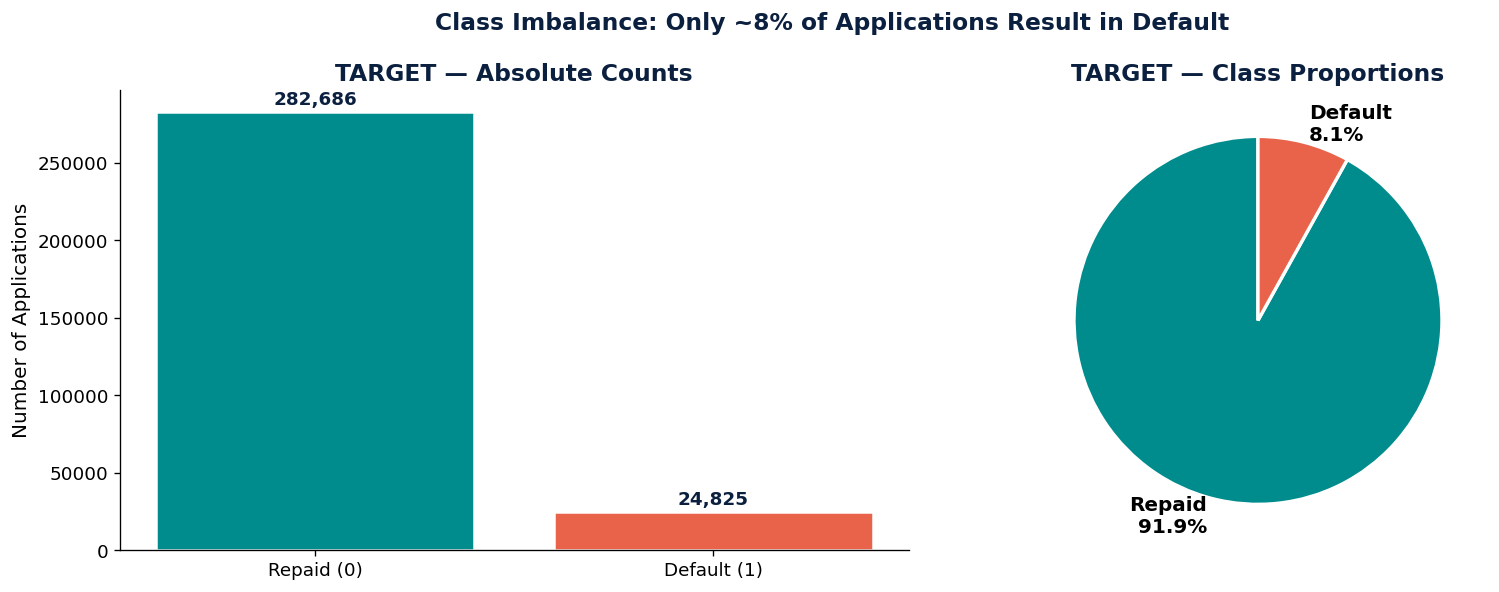

In [17]:
# YOUR CODE: Visualise the TARGET distribution
# Create a bar chart showing counts for TARGET=0 and TARGET=1
# Calculate the default rate as a percentage

# TARGET Variable Distribution
target_counts = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100

print("Target Distribution:")
print(f"  Repaid (0): {target_counts[0]:,}  ({target_pct[0]:.2f}%)")
print(f"  Default (1): {target_counts[1]:,}  ({target_pct[1]:.2f}%)")
print(f"\nDefault Rate: {app_train['TARGET'].mean():.2%}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count bar chart
bars = axes[0].bar(['Repaid (0)', 'Default (1)'],
                   [target_counts[0], target_counts[1]],
                   color=[TEAL, CORAL], edgecolor='white', linewidth=1.5)
axes[0].set_title('TARGET — Absolute Counts', color=NAVY, fontweight='bold')
axes[0].set_ylabel('Number of Applications')
for bar, count in zip(bars, [target_counts[0], target_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', color=NAVY)

# Percentage pie chart
axes[1].pie([target_pct[0], target_pct[1]],
            labels=[f'Repaid\n{target_pct[0]:.1f}%', f'Default\n{target_pct[1]:.1f}%'],
            colors=[TEAL, CORAL], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('TARGET — Class Proportions', color=NAVY, fontweight='bold')

plt.suptitle('Class Imbalance: Only ~8% of Applications Result in Default',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Use <code>app_train['TARGET'].value_counts()</code> for counts and add <code>normalize=True</code> for percentages.</span>
</div>

<div style="background: #FDE8E5; border-left: 5px solid #E8634A; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #E8634A;">⚠️ Important</strong><br>
<span style="color: #333;"><strong>Class Imbalance Alert:</strong> Only ~8% of applications result in default. This means a model that predicts “no default” for every application would be 92% accurate — but completely useless. This is why we will use <strong>AUC-ROC</strong> and <strong>AUC-PR</strong> as our primary metrics, not accuracy.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 4: Feature Landscape</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Surveying the 122 columns — types, ranges, and distributions</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Build a comprehensive overview of all features: data types, unique values, value ranges, and basic distribution statistics.</span>
</div>

<div style="background: #FDF6E8; border: 2px solid #B8953E; padding: 10px 18px; border-radius: 8px; margin: 20px 0 8px 0;">
<h3 style="color: #0B1F3F; margin: 0;">✏️ Exercise 2: Descriptive Statistics for Key Numeric Features</h3>
</div>

In [7]:
# Descriptive statistics for key numeric features
key_numeric = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
               'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
               'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

stats_df = app_train[key_numeric].describe().T
stats_df['missing_%'] = (app_train[key_numeric].isnull().sum() / len(app_train) * 100).round(2)
stats_df


,count,mean,std,min,25%,50%,75%,max,missing_%
AMT_INCOME_TOTAL,"307,511.00","168,797.92","237,123.15","25,650.00","112,500.00","147,150.00","202,500.00","117,000,000.00",0.00
AMT_CREDIT,"307,511.00","599,026.00","402,490.78","45,000.00","270,000.00","513,531.00","808,650.00","4,050,000.00",0.00
AMT_ANNUITY,"307,499.00","27,108.57","14,493.74","1,615.50","16,524.00","24,903.00","34,596.00","258,025.50",0.00
AMT_GOODS_PRICE,"307,233.00","538,396.21","369,446.46","40,500.00","238,500.00","450,000.00","679,500.00","4,050,000.00",0.09
DAYS_BIRTH,"307,511.00","-16,037.00","4,363.99","-25,229.00","-19,682.00","-15,750.00","-12,413.00","-7,489.00",0.00
DAYS_EMPLOYED,"307,511.00","63,815.05","141,275.77","-17,912.00","-2,760.00","-1,213.00",-289.00,"365,243.00",0.00
EXT_SOURCE_1,"134,133.00",0.50,0.21,0.01,0.33,0.51,0.68,0.96,56.38
EXT_SOURCE_2,"306,851.00",0.51,0.19,0.00,0.39,0.57,0.66,0.85,0.21
EXT_SOURCE_3,"246,546.00",0.51,0.19,0.00,0.37,0.54,0.67,0.90,19.83
CNT_CHILDREN,"307,511.00",0.42,0.72,0.00,0.00,0.00,1.00,19.00,0.00


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Use <code>.describe().T</code> for a transposed summary. Add missingness with <code>app_train[cols].isnull().sum() / len(app_train) * 100</code>.</span>
</div>

<div style="background: linear-gradient(90deg, #E0F2F2, #FDF6E8); border-left: 5px solid #008C8C; border-right: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🧠 Interpretation</strong><br>
<span style="color: #333;"><strong>What to notice:</strong><br>• <strong>DAYS_BIRTH</strong> ranges from about -25,000 to -7,000 (i.e., applicants are 19–68 years old). Negative because it’s days before application.<br>• <strong>DAYS_EMPLOYED</strong> has a suspicious maximum of 365,243 — roughly 1,000 years. This is clearly an anomaly.<br>• <strong>AMT_INCOME_TOTAL</strong> ranges from ~26K to 117M — extreme right skew suggests outlier handling will be needed.<br>• <strong>EXT_SOURCE_1</strong> is 56% missing, while EXT_SOURCE_2 is nearly complete.</span>
</div>

<div style="background: #FDF6E8; border: 2px solid #B8953E; padding: 10px 18px; border-radius: 8px; margin: 20px 0 8px 0;">
<h3 style="color: #0B1F3F; margin: 0;">✏️ Exercise 3: Categorical Feature Exploration</h3>
</div>

In [8]:
# Categorical feature summary
cat_cols = app_train.select_dtypes(include=[object]).columns

cat_summary = []
for col in cat_cols:
    top_val = app_train[col].value_counts(normalize=True)
    cat_summary.append({
        'Column': col,
        'Unique Values': app_train[col].nunique(),
        'Missing %': round(app_train[col].isnull().mean() * 100, 2),
        'Top Value': top_val.index[0] if len(top_val) > 0 else 'N/A',
        'Top Value %': round(top_val.iloc[0] * 100, 1) if len(top_val) > 0 else 0
    })

cat_summary_df = pd.DataFrame(cat_summary).sort_values('Unique Values')
cat_summary_df


,Column,Unique Values,Missing %,Top Value,Top Value %
0,NAME_CONTRACT_TYPE,2,0.00,Cash loans,90.50
2,FLAG_OWN_CAR,2,0.00,N,66.00
3,FLAG_OWN_REALTY,2,0.00,Y,69.40
15,EMERGENCYSTATE_MODE,2,47.40,No,98.60
13,HOUSETYPE_MODE,3,50.18,block of flats,98.20
1,CODE_GENDER,3,0.00,F,65.80
12,FONDKAPREMONT_MODE,4,68.39,reg oper account,75.90
6,NAME_EDUCATION_TYPE,5,0.00,Secondary / secondary special,71.00
7,NAME_FAMILY_STATUS,6,0.00,Married,63.90
8,NAME_HOUSING_TYPE,6,0.00,House / apartment,88.70


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Get categorical columns with <code>app_train.select_dtypes(include=[object]).columns</code>. Loop through and compute <code>.nunique()</code> and <code>.value_counts(normalize=True)</code>.</span>
</div>

<div style="background: #FDF6E8; border: 2px solid #B8953E; padding: 10px 18px; border-radius: 8px; margin: 20px 0 8px 0;">
<h3 style="color: #0B1F3F; margin: 0;">✏️ Exercise 4: Distribution Visualisations</h3>
</div>

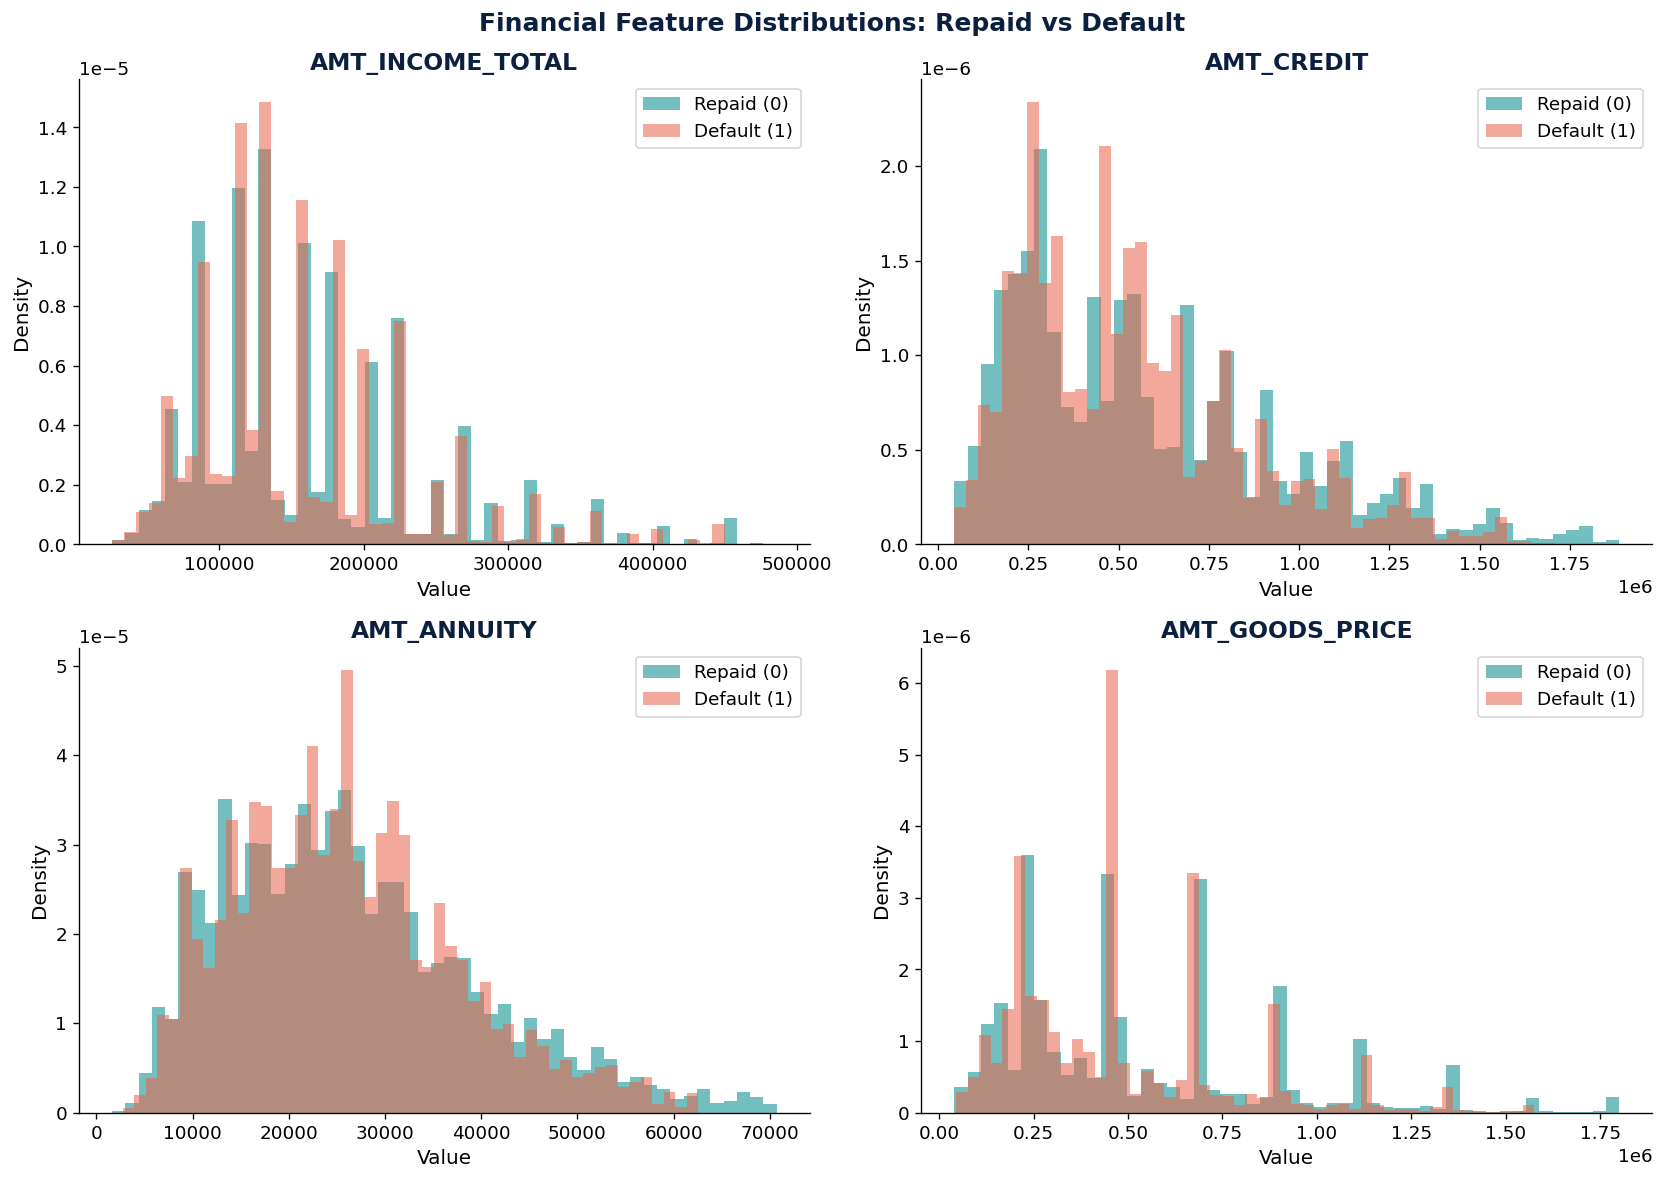

In [9]:
# Distribution plots split by TARGET
plot_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feat in enumerate(plot_features):
    for target_val, color, label in [(0, TEAL, 'Repaid (0)'), (1, CORAL, 'Default (1)')]:
        subset = app_train[app_train['TARGET'] == target_val][feat].dropna()
        q99 = subset.quantile(0.99)
        subset = subset[subset <= q99]
        axes[i].hist(subset, bins=50, alpha=0.55, color=color, label=label, density=True)
    axes[i].set_title(feat, color=NAVY, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Financial Feature Distributions: Repaid vs Default', fontsize=15,
             color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Loop through features. For each, filter <code>app_train[app_train['TARGET']==0]</code> and <code>==1</code>. Use <code>density=True</code> in <code>plt.hist()</code> since the classes are imbalanced.</span>
</div>

<div style="background: #E0F2F2; border-left: 5px solid #008C8C; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #008C8C;">📊 Business Insight</strong><br>
<span style="color: #333;">The distributions for Repaid vs Default applicants overlap heavily for most financial features. This tells us that no single feature cleanly separates the two groups — we will need combinations of features and sophisticated models to achieve good discrimination.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 5: The DAYS_EMPLOYED Anomaly</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Detecting and handling a critical data quality issue</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Identify the anomalous value in DAYS_EMPLOYED, understand its impact, and implement a cleaning strategy.</span>
</div>

Records with DAYS_EMPLOYED = 365243 : 55,374
As % of total                        : 18.01%


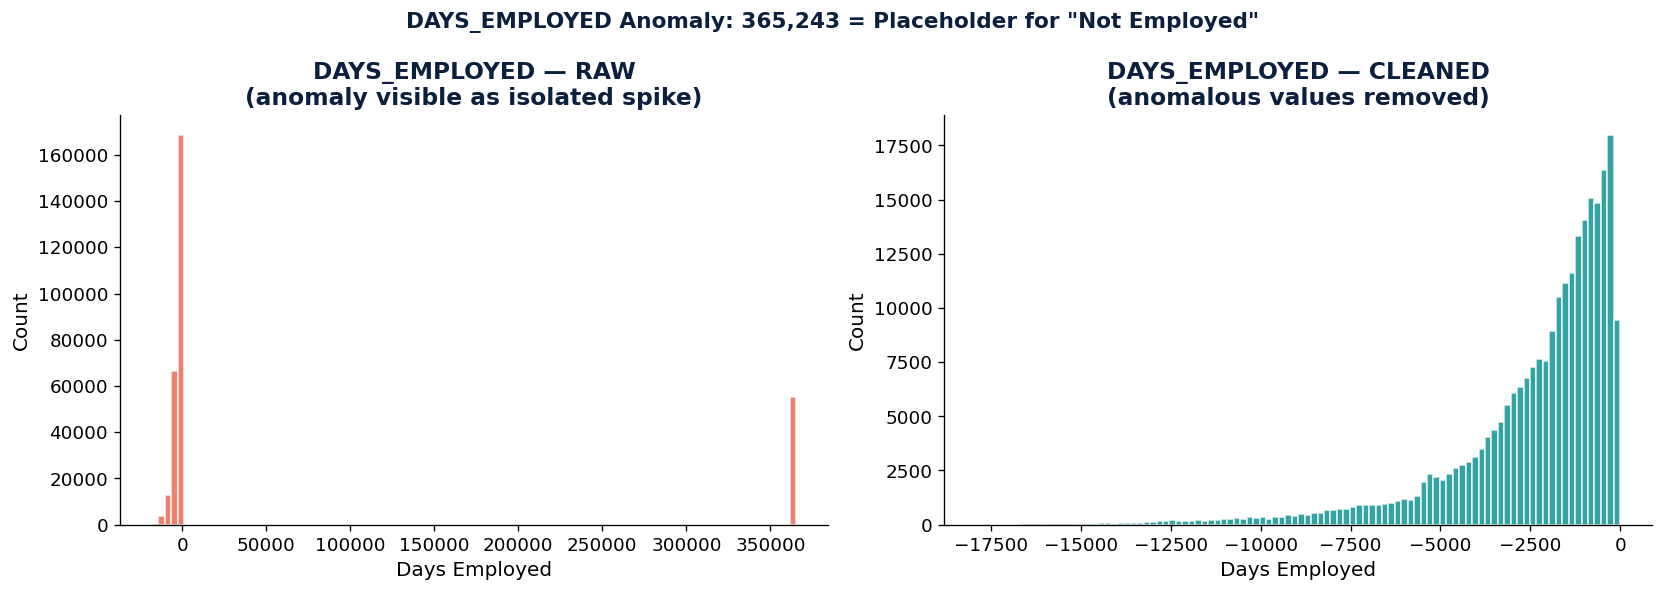


✅ DAYS_EMPLOYED_ANOMALY flag created
   0 = Normal employment record : 252,137
   1 = Anomalous (365,243)       : 55,374

Default Rate Comparison:
  Normal records   (flag=0) : 8.66%
  Anomalous records(flag=1) : 5.40%


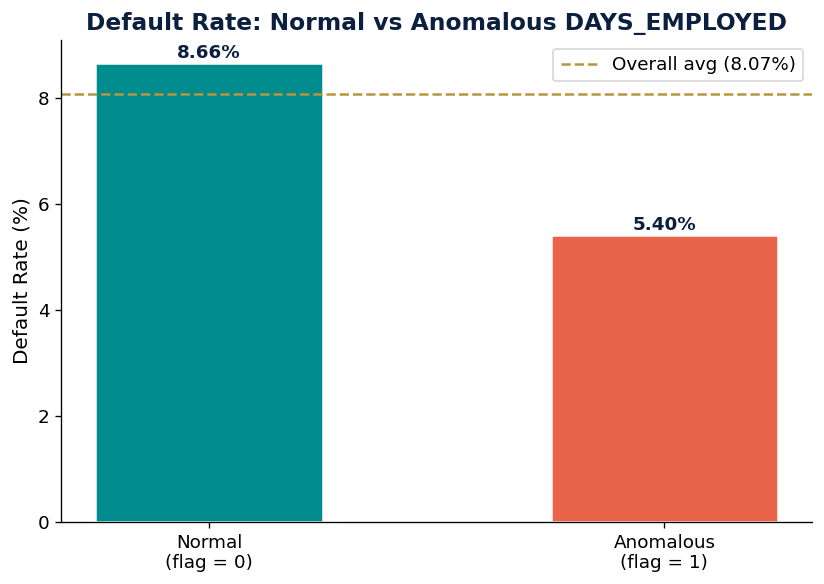

In [18]:
# YOUR CODE: 
# 1. Find how many times the value 365243 appears in DAYS_EMPLOYED
# 2. Visualise the distribution before and after removing this anomaly
# 3. Create a binary flag column DAYS_EMPLOYED_ANOMALY
# 4. Compare default rates between anomalous and normal records

# ── 1. Count anomalous records ──
anomaly_count = (app_train['DAYS_EMPLOYED'] == 365243).sum()
print(f"Records with DAYS_EMPLOYED = 365243 : {anomaly_count:,}")
print(f"As % of total                        : {anomaly_count/len(app_train):.2%}")

# ── 2. Visualise BEFORE vs AFTER ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before — shows the giant spike at 365,243
axes[0].hist(app_train['DAYS_EMPLOYED'], bins=100, color=CORAL, alpha=0.8, edgecolor='white')
axes[0].set_title('DAYS_EMPLOYED — RAW\n(anomaly visible as isolated spike)', 
                  color=NAVY, fontweight='bold')
axes[0].set_xlabel('Days Employed')
axes[0].set_ylabel('Count')

# After — clean distribution only
clean_vals = app_train['DAYS_EMPLOYED'].replace(365243, np.nan).dropna()
axes[1].hist(clean_vals, bins=100, color=TEAL, alpha=0.8, edgecolor='white')
axes[1].set_title('DAYS_EMPLOYED — CLEANED\n(anomalous values removed)', 
                  color=NAVY, fontweight='bold')
axes[1].set_xlabel('Days Employed')
axes[1].set_ylabel('Count')

plt.suptitle('DAYS_EMPLOYED Anomaly: 365,243 = Placeholder for "Not Employed"',
             fontsize=13, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Create flag and clean column ──
app_train['DAYS_EMPLOYED_ANOMALY'] = (app_train['DAYS_EMPLOYED'] == 365243).astype(int)
app_train['DAYS_EMPLOYED_CLEAN']   = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)

print(f"\n✅ DAYS_EMPLOYED_ANOMALY flag created")
print(f"   0 = Normal employment record : {(app_train['DAYS_EMPLOYED_ANOMALY']==0).sum():,}")
print(f"   1 = Anomalous (365,243)       : {(app_train['DAYS_EMPLOYED_ANOMALY']==1).sum():,}")

# ── 4. Compare default rates ──
default_by_flag = app_train.groupby('DAYS_EMPLOYED_ANOMALY')['TARGET'].mean() * 100

print(f"\nDefault Rate Comparison:")
print(f"  Normal records   (flag=0) : {default_by_flag[0]:.2f}%")
print(f"  Anomalous records(flag=1) : {default_by_flag[1]:.2f}%")

# Bar chart for default rate comparison
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Normal\n(flag = 0)', 'Anomalous\n(flag = 1)'],
              [default_by_flag[0], default_by_flag[1]],
              color=[TEAL, CORAL], edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Default Rate: Normal vs Anomalous DAYS_EMPLOYED',
             color=NAVY, fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.axhline(app_train['TARGET'].mean() * 100, color=GOLD, linestyle='--',
           linewidth=1.5, label=f'Overall avg ({app_train["TARGET"].mean():.2%})')
for bar, val in zip(bars, [default_by_flag[0], default_by_flag[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', fontweight='bold', color=NAVY)
ax.legend()
plt.tight_layout()
plt.show()



<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Check for the anomaly with <code>(app_train['DAYS_EMPLOYED'] == 365243).sum()</code>. Create a flag: <code>app_train['DAYS_EMPLOYED_ANOMALY'] = (app_train['DAYS_EMPLOYED'] == 365243).astype(int)</code>. Replace with NaN: <code>.replace(365243, np.nan)</code>.</span>
</div>

<div style="background: linear-gradient(90deg, #E0F2F2, #FDF6E8); border-left: 5px solid #008C8C; border-right: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🧠 Interpretation</strong><br>
<span style="color: #333;"><strong>Key Finding:</strong> The anomalous records (where DAYS_EMPLOYED = 365,243) actually have a <em>lower</em> default rate (~5.4%) compared to normal records (~8.7%). This suggests these are not random errors — the value likely represents pensioners, homemakers, or other groups with no traditional employment. The binary flag we created (DAYS_EMPLOYED_ANOMALY) will itself be a useful feature.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 6: External Score Deep Dive</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">The three most powerful features in the dataset</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Explore EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 — their distributions, correlations with TARGET, and inter-relationships.</span>
</div>

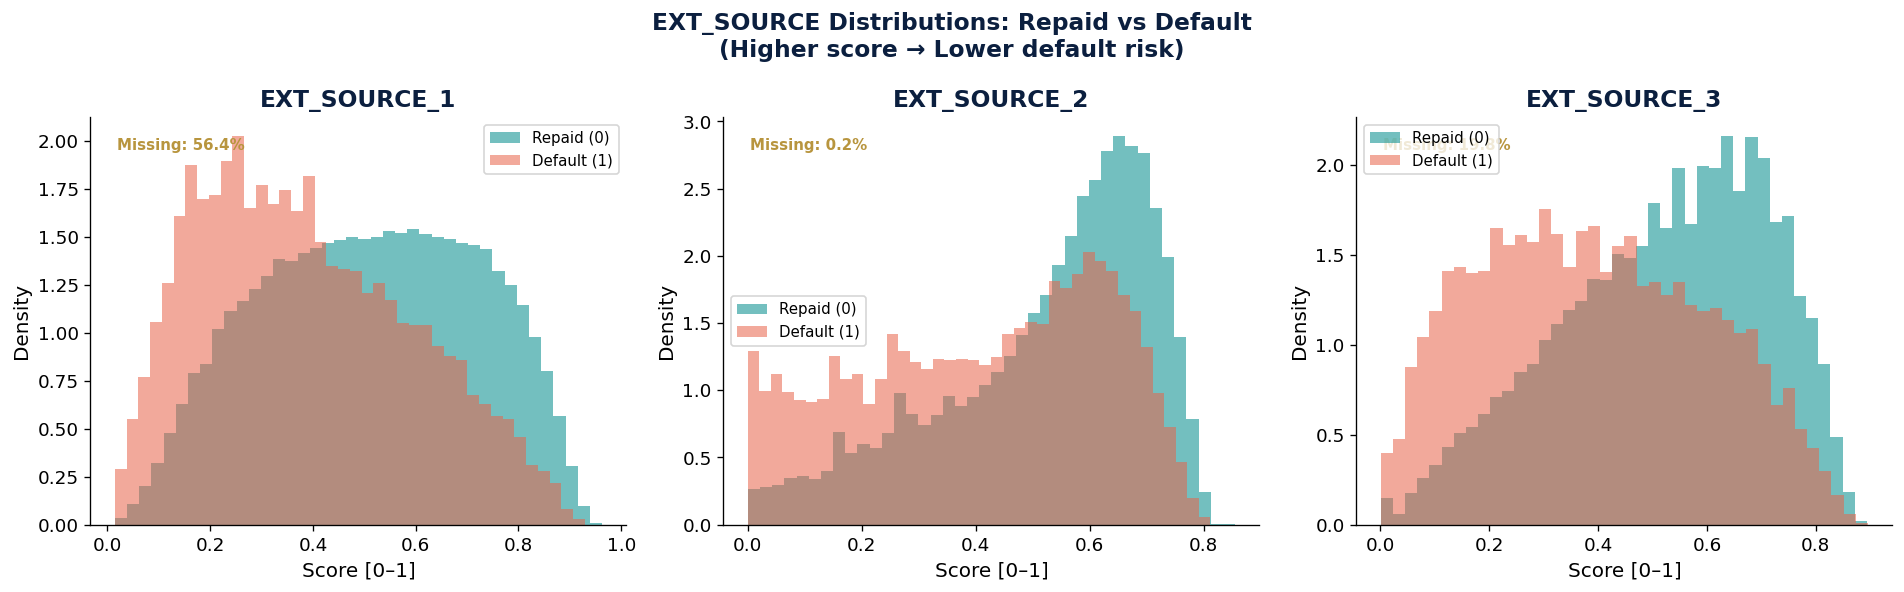

Pearson Correlations with TARGET:
-----------------------------------
  EXT_SOURCE_1:  r = -0.1553   |   Missing: 56.4%
  EXT_SOURCE_2:  r = -0.1605   |   Missing: 0.2%
  EXT_SOURCE_3:  r = -0.1789   |   Missing: 19.8%


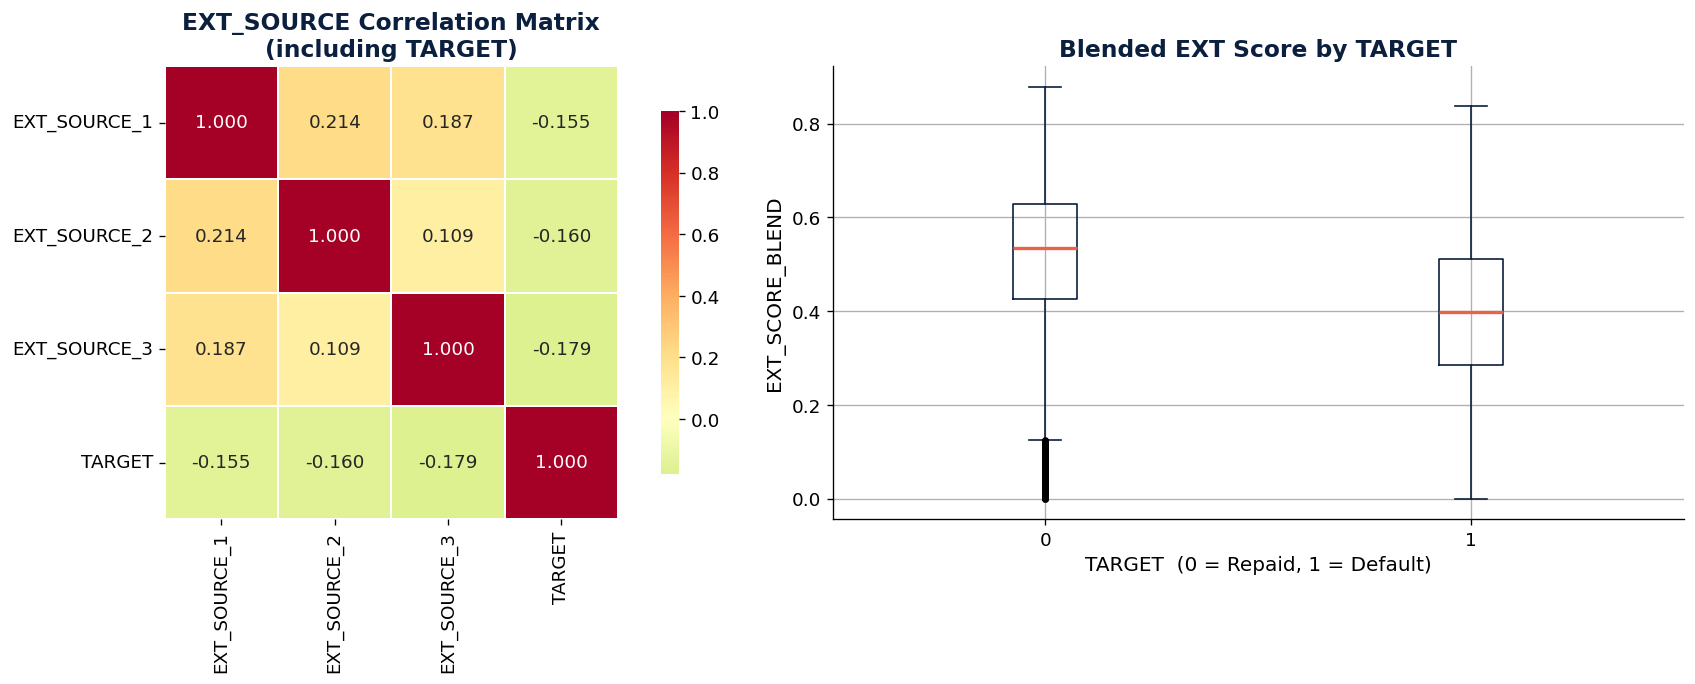


EXT_SCORE_BLEND — Mean by TARGET:
-----------------------------------
             mean  median  std
Repaid (0)   0.52    0.53 0.14
Default (1)  0.40    0.40 0.16


In [19]:
# YOUR CODE:
# 1. Plot distributions of EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3, split by TARGET
# 2. Compute their correlations with TARGET
# 3. Build a correlation heatmap for these 3 features + TARGET

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# ── 1. Distribution plots split by TARGET ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(ext_cols):
    for target_val, color, label in [(0, TEAL, 'Repaid (0)'), (1, CORAL, 'Default (1)')]:
        subset = app_train[app_train['TARGET'] == target_val][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True)
    
    axes[i].set_title(col, color=NAVY, fontweight='bold')
    axes[i].set_xlabel('Score [0–1]')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    
    # Add missingness annotation
    miss_pct = app_train[col].isnull().mean() * 100
    axes[i].annotate(f'Missing: {miss_pct:.1f}%', xy=(0.05, 0.92),
                     xycoords='axes fraction', fontsize=9,
                     color=GOLD, fontweight='bold')

plt.suptitle('EXT_SOURCE Distributions: Repaid vs Default\n'
             '(Higher score → Lower default risk)',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Correlations with TARGET ──
print("Pearson Correlations with TARGET:")
print("-" * 35)
for col in ext_cols:
    corr = app_train[col].corr(app_train['TARGET'])
    miss = app_train[col].isnull().mean() * 100
    print(f"  {col}:  r = {corr:.4f}   |   Missing: {miss:.1f}%")

# ── 3. Correlation heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr_matrix = app_train[ext_cols + ['TARGET']].corr()
mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask, k=1)] = True  # show full matrix

sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='RdYlGn_r', center=0,
            linewidths=1, linecolor='white',
            ax=axes[0], square=True,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('EXT_SOURCE Correlation Matrix\n(including TARGET)',
                  color=NAVY, fontweight='bold')

# ── 4. Blended score vs TARGET (bonus boxplot) ──
app_train['EXT_SCORE_BLEND'] = app_train[ext_cols].mean(axis=1)

app_train.boxplot(column='EXT_SCORE_BLEND', by='TARGET',
                  ax=axes[1],
                  boxprops=dict(color=NAVY),
                  medianprops=dict(color=CORAL, linewidth=2),
                  whiskerprops=dict(color=NAVY),
                  capprops=dict(color=NAVY),
                  flierprops=dict(marker='o', alpha=0.2,
                                  color=TEAL, markersize=3))
axes[1].set_title('Blended EXT Score by TARGET',
                  color=NAVY, fontweight='bold')
axes[1].set_xlabel('TARGET  (0 = Repaid, 1 = Default)')
axes[1].set_ylabel('EXT_SCORE_BLEND')
plt.sca(axes[1])
plt.title('Blended EXT Score by TARGET', color=NAVY, fontweight='bold')
plt.suptitle('')  # suppress auto suptitle from boxplot

plt.tight_layout()
plt.show()

# ── 5. Summary table ──
print("\nEXT_SCORE_BLEND — Mean by TARGET:")
print("-" * 35)
blend_summary = app_train.groupby('TARGET')['EXT_SCORE_BLEND'].agg(['mean','median','std'])
blend_summary.index = ['Repaid (0)', 'Default (1)']
print(blend_summary.round(4))


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Compute correlation with <code>app_train['EXT_SOURCE_2'].corr(app_train['TARGET'])</code>. For the heatmap, use <code>sns.heatmap(app_train[ext_cols].corr(), annot=True)</code>.</span>
</div>

<div style="background: #E0F2F2; border-left: 5px solid #008C8C; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #008C8C;">📊 Business Insight</strong><br>
<span style="color: #333;"><strong>These three features are the most predictive in the entire dataset.</strong> EXT_SOURCE_2 (corr ≈ -0.16) and EXT_SOURCE_3 (corr ≈ -0.18) show that higher external scores are strongly associated with lower default probability. Even EXT_SOURCE_1 (56% missing) is valuable. The three scores are only weakly correlated with each other, meaning they capture different aspects of creditworthiness. A blended score combining all three will be a powerful feature.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 7: Missingness Audit</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Mapping the holes in our data</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Create a comprehensive missingness report, classify missing data mechanisms, and visualise patterns.</span>
</div>

In [20]:
# Missingness Report
missing_report = pd.DataFrame({
    'Missing Count': app_train.isnull().sum(),
    'Missing %': (app_train.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing_report = missing_report[missing_report['Missing Count'] > 0]
print(f"Columns with missing values: {len(missing_report)} out of {app_train.shape[1]}")
print()
missing_report.head(30)


Columns with missing values: 69 out of 125



,Missing Count,Missing %
COMMONAREA_AVG,214865,69.87
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_AVG,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Use <code>app_train.isnull().sum()</code> for counts. Divide by <code>len(app_train)</code> for percentages. Sort with <code>.sort_values('Missing %', ascending=False)</code>.</span>
</div>

<div style="background: #FDF6E8; border: 2px solid #B8953E; padding: 10px 18px; border-radius: 8px; margin: 20px 0 8px 0;">
<h3 style="color: #0B1F3F; margin: 0;">✏️ Exercise 5: Missingness Heatmap</h3>
</div>

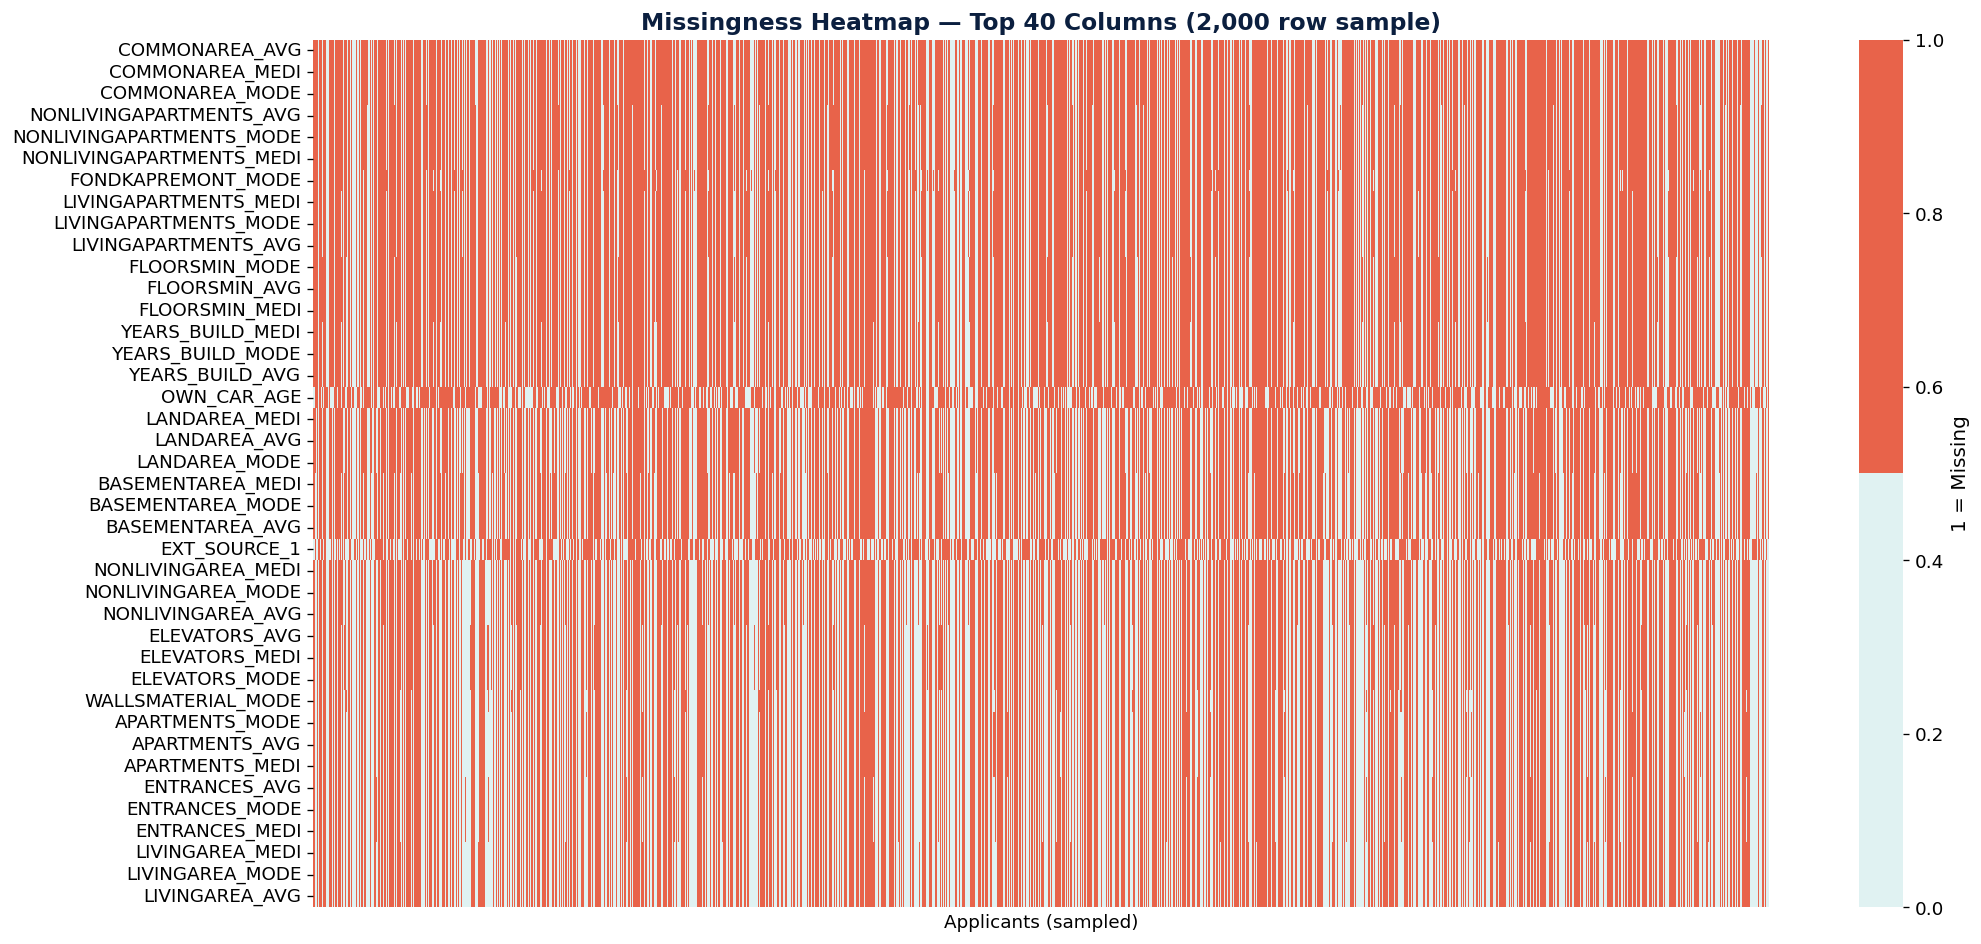

In [21]:
# Missingness Heatmap — top 40 most-missing columns
top_missing_cols = (app_train.isnull().mean()
                    .sort_values(ascending=False)
                    .head(40).index.tolist())

# Sample 2000 rows for performance
sample_df = app_train[top_missing_cols].sample(2000, random_state=42)
missing_matrix = sample_df.isnull().astype(int)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(missing_matrix.T, cmap=['#E0F2F2', CORAL],
            xticklabels=False, yticklabels=True, ax=ax,
            cbar_kws={'label': '1 = Missing'})
ax.set_title('Missingness Heatmap — Top 40 Columns (2,000 row sample)',
             color=NAVY, fontweight='bold', fontsize=14)
ax.set_xlabel('Applicants (sampled)', fontsize=11)
plt.tight_layout()
plt.show()


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Create a binary matrix: <code>app_train[cols].isnull().astype(int)</code>. Use <code>sns.heatmap()</code> with a 2-color colormap.</span>
</div>

<div style="background: linear-gradient(90deg, #E0F2F2, #FDF6E8); border-left: 5px solid #008C8C; border-right: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🧠 Interpretation</strong><br>
<span style="color: #333;"><strong>Missingness patterns reveal structure:</strong> You should see blocks of columns that are missing together (e.g., all housing-related features missing for the same applicants). This is a sign of MAR (Missing at Random) — the data is missing because those applicants don’t own property. The FLAG_DOCUMENT columns have very different missingness patterns, suggesting independent data collection processes.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 8: Multi-Table Schema</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Loading auxiliary tables and understanding the star schema</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Load all auxiliary tables, understand their granularity, and verify the schema relationships.</span>
</div>

In [22]:
# Load all auxiliary tables
DATA_DIR = '../data/home-credit-default-risk/'

table_names = [
    'bureau', 'bureau_balance', 'previous_application',
    'POS_CASH_balance', 'credit_card_balance', 'installments_payments'
]

tables = {}
print(f"{'Table':<30} {'Rows':>12} {'Cols':>6}  Join Key")
print("-" * 62)
join_keys = {
    'bureau': 'SK_ID_CURR', 'bureau_balance': 'SK_ID_BUREAU',
    'previous_application': 'SK_ID_CURR', 'POS_CASH_balance': 'SK_ID_PREV',
    'credit_card_balance': 'SK_ID_PREV', 'installments_payments': 'SK_ID_PREV'
}
for name in table_names:
    try:
        df_tmp = pd.read_csv(os.path.join(DATA_DIR, f'{name}.csv'))
        tables[name] = df_tmp
        print(f"{name:<30} {df_tmp.shape[0]:>12,} {df_tmp.shape[1]:>6}  {join_keys[name]}")
    except FileNotFoundError:
        print(f"{name:<30}  [FILE NOT FOUND - update DATA_DIR]")


Table                                  Rows   Cols  Join Key
--------------------------------------------------------------
bureau                          [FILE NOT FOUND - update DATA_DIR]
bureau_balance                  [FILE NOT FOUND - update DATA_DIR]
previous_application            [FILE NOT FOUND - update DATA_DIR]
POS_CASH_balance                [FILE NOT FOUND - update DATA_DIR]
credit_card_balance             [FILE NOT FOUND - update DATA_DIR]
installments_payments           [FILE NOT FOUND - update DATA_DIR]


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Use a loop: <code>for name in ['bureau', 'bureau_balance', ...]: pd.read_csv(f'{DATA_DIR}/{name}.csv')</code></span>
</div>

<div style="background: #E0F2F2; border-left: 5px solid #008C8C; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #008C8C;">📊 Business Insight</strong><br>
<span style="color: #333;"><strong>Not all clients appear in all tables.</strong> The bureau table contains only ~263K unique SK_ID_CURR values out of 307K in the application table. This means ~44K applicants have no Credit Bureau history at all. These “thin-file” applicants are precisely the population Home Credit serves — and the hardest to score.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 9: Join Strategy & Aggregation</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Safely combining multi-table data without inflating rows</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Aggregate the bureau table to the client level and join it to the main application table, preserving the correct granularity.</span>
</div>

<div style="background: #FDE8E5; border-left: 5px solid #E8634A; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #E8634A;">⚠️ Important</strong><br>
<span style="color: #333;"><strong>The #1 mistake in multi-table analytics:</strong> Joining a one-to-many table directly will duplicate your rows. If a client has 5 bureau credits, a direct merge creates 5 rows for that client. Always <strong>aggregate first, then join</strong>.</span>
</div>

Loaded bureau: (1716428, 17)

bureau shape (before agg) : (1716428, 17)
Unique SK_ID_CURR in bureau: 305,811
Unique SK_ID_CURR in train : 307,511
Thin-file clients (no CB)  : 1,700

✅ Bureau aggregated shape : (305811, 12)
   New features created    : 11

Sample of aggregated bureau:
✅ Row count verified      : 307,511  (matches app_train exactly)
   Columns before join     : 125
   Columns after join      : 136
   New bureau columns added: 11

Clients with NO bureau history (thin-file): 44,020  (14.3% of all applicants)

Bureau feature means by TARGET:
-------------------------------------------------------
                     Repaid (0)  Default (1)
bureau_credit_count        5.56         5.62
bureau_active_ratio        0.41         0.50
bureau_debt_sum      637,271.68   680,978.73
bureau_max_overdue     9,123.59    12,599.60


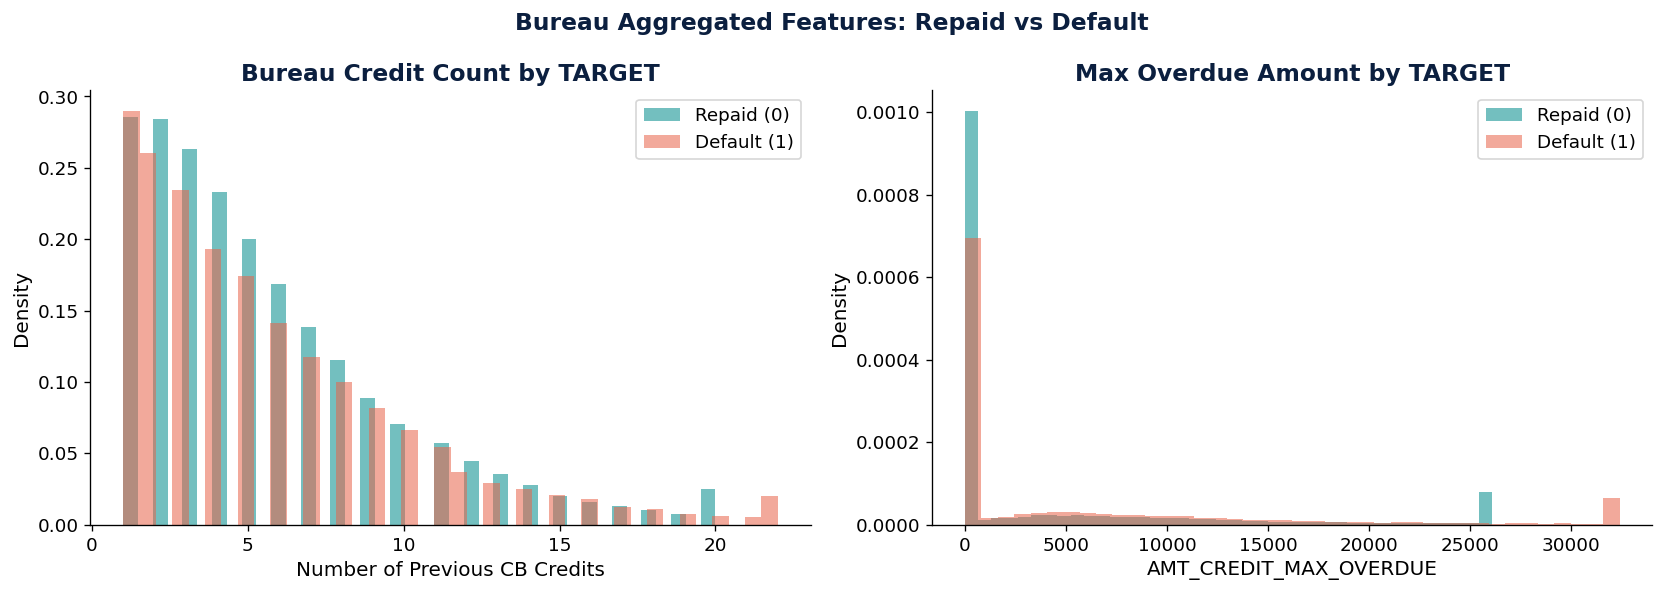


➡️  df now contains app_train + all bureau aggregations — ready for modelling.


In [27]:
# YOUR CODE:
# 1. Aggregate the bureau table to SK_ID_CURR level with these statistics:
#    - Count of credits, count active, count closed
#    - Mean/min of DAYS_CREDIT, mean/max of AMT_CREDIT_SUM
#    - Sum of AMT_CREDIT_SUM_DEBT, max of AMT_CREDIT_MAX_OVERDUE
# 2. LEFT join to app_train on SK_ID_CURR
# 3. VERIFY the row count hasn't changed!


# ── Update DATA_DIR to your actual path ──
DATA_DIR = r'C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\April 1'

# ── Load bureau if not already in memory ──
try:
    bureau
    print("✅ bureau already loaded")
except NameError:
    bureau = pd.read_csv(os.path.join(DATA_DIR, 'bureau.csv'))
    print(f"Loaded bureau: {bureau.shape}")

print(f"\nbureau shape (before agg) : {bureau.shape}")
print(f"Unique SK_ID_CURR in bureau: {bureau['SK_ID_CURR'].nunique():,}")
print(f"Unique SK_ID_CURR in train : {app_train['SK_ID_CURR'].nunique():,}")
print(f"Thin-file clients (no CB)  : {app_train['SK_ID_CURR'].nunique() - bureau['SK_ID_CURR'].nunique():,}")

# ── 1. Aggregate bureau to SK_ID_CURR level ──
bureau_agg = bureau.groupby('SK_ID_CURR').agg(

    # Credit counts
    bureau_credit_count     = ('SK_ID_BUREAU',            'count'),
    bureau_active_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    bureau_closed_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),

    # Days credit
    bureau_days_credit_mean = ('DAYS_CREDIT',             'mean'),
    bureau_days_credit_min  = ('DAYS_CREDIT',             'min'),

    # Credit amounts
    bureau_credit_sum_mean  = ('AMT_CREDIT_SUM',          'mean'),
    bureau_credit_sum_max   = ('AMT_CREDIT_SUM',          'max'),

    # Debt & overdue
    bureau_debt_sum         = ('AMT_CREDIT_SUM_DEBT',     'sum'),
    bureau_max_overdue      = ('AMT_CREDIT_MAX_OVERDUE',  'max'),
    bureau_overdue_sum      = ('AMT_CREDIT_SUM_OVERDUE',  'sum'),

).reset_index()

# Derived ratio: active credits / total credits
bureau_agg['bureau_active_ratio'] = (
    bureau_agg['bureau_active_count'] / bureau_agg['bureau_credit_count']
)

print(f"\n✅ Bureau aggregated shape : {bureau_agg.shape}")
print(f"   New features created    : {bureau_agg.shape[1] - 1}")
print()
print("Sample of aggregated bureau:")
bureau_agg.head(3)


# ── 2. LEFT join to app_train ──
df = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

# ── 3. VERIFY row count ──
assert len(df) == len(app_train), \
    f"❌ Row count mismatch! Expected {len(app_train):,}, got {len(df):,}"

print(f"✅ Row count verified      : {len(df):,}  (matches app_train exactly)")
print(f"   Columns before join     : {app_train.shape[1]}")
print(f"   Columns after join      : {df.shape[1]}")
print(f"   New bureau columns added: {df.shape[1] - app_train.shape[1]}")
print()

# ── 4. Check NaN coverage (thin-file clients) ──
thin_file = df['bureau_credit_count'].isna().sum()
print(f"Clients with NO bureau history (thin-file): {thin_file:,}  "
      f"({thin_file/len(df):.1%} of all applicants)")
print()

# ── 5. Spot-check: do bureau features differ by TARGET? ──
check_cols = ['bureau_credit_count', 'bureau_active_ratio',
              'bureau_debt_sum', 'bureau_max_overdue']

print("Bureau feature means by TARGET:")
print("-" * 55)
summary = df.groupby('TARGET')[check_cols].mean().round(2)
summary.index = ['Repaid (0)', 'Default (1)']
print(summary.T.to_string())

# ── 6. Visualise bureau_credit_count and bureau_max_overdue by TARGET ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target_val, color, label in [(0, TEAL, 'Repaid (0)'), (1, CORAL, 'Default (1)')]:
    subset = df[df['TARGET'] == target_val]

    # Credit count distribution
    vals = subset['bureau_credit_count'].dropna()
    axes[0].hist(vals.clip(upper=vals.quantile(0.99)),
                 bins=40, alpha=0.55, color=color,
                 label=label, density=True)

    # Max overdue distribution
    vals2 = subset['bureau_max_overdue'].dropna()
    axes[1].hist(vals2.clip(upper=vals2.quantile(0.95)),
                 bins=40, alpha=0.55, color=color,
                 label=label, density=True)

axes[0].set_title('Bureau Credit Count by TARGET',   color=NAVY, fontweight='bold')
axes[0].set_xlabel('Number of Previous CB Credits')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('Max Overdue Amount by TARGET',    color=NAVY, fontweight='bold')
axes[1].set_xlabel('AMT_CREDIT_MAX_OVERDUE')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Bureau Aggregated Features: Repaid vs Default',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n➡️  df now contains app_train + all bureau aggregations — ready for modelling.")

<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">Aggregate: <code>bureau.groupby('SK_ID_CURR').agg({...})</code>. Join: <code>app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')</code>. Critical check: <code>assert len(result) == len(app_train)</code></span>
</div>

<div style="background: linear-gradient(90deg, #E0F2F2, #FDF6E8); border-left: 5px solid #008C8C; border-right: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🧠 Interpretation</strong><br>
<span style="color: #333;"><strong>Row count preserved ✓</strong> The left join should keep exactly 307,511 rows. Clients with no bureau history will have NaN in the new columns — that’s correct and expected. About 44K clients (~14%) will have NaN bureau features. These “thin-file” borrowers are a distinct analytical segment.</span>
</div>

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 10: KPI Mapping</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">Translating raw columns into business-meaningful metrics</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Create derived KPIs that translate technical column names into boardroom language.</span>
</div>

In [28]:
# Derived KPI Engineering

kpis = ['AGE_YEARS', 'EMPLOYMENT_YEARS', 'DEBT_TO_INCOME', 'ANNUITY_BURDEN',
        'CREDIT_GOODS_RATIO', 'EXT_SCORE_BLEND']

df['AGE_YEARS']         = -df['DAYS_BIRTH'] / 365
df['EMPLOYMENT_YEARS']  = -df['DAYS_EMPLOYED_CLEAN'] / 365
df['DEBT_TO_INCOME']    = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_BURDEN']    = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_GOODS_RATIO']= df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
df['EXT_SCORE_BLEND']   = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

print("KPI means by TARGET (0 = Repaid, 1 = Default):")
print()
print(df.groupby('TARGET')[kpis].mean().round(3).T.rename(columns={0: 'Repaid', 1: 'Default'}))


KPI means by TARGET (0 = Repaid, 1 = Default):

TARGET              Repaid  Default
AGE_YEARS            44.21    40.78
EMPLOYMENT_YEARS      6.68     4.97
DEBT_TO_INCOME        3.96     3.89
ANNUITY_BURDEN        0.18     0.18
CREDIT_GOODS_RATIO    1.12     1.15
EXT_SCORE_BLEND       0.52     0.40


<div style="background: #FDF6E8; border-left: 5px solid #B8953E; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #B8953E;">💡 Hint</strong><br>
<span style="color: #555;">For the blended score: <code>df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)</code>. Group comparison: <code>df.groupby('TARGET')[kpi_cols].mean()</code>.</span>
</div>

<div style="background: #E0F2F2; border-left: 5px solid #008C8C; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #008C8C;">📊 Business Insight</strong><br>
<span style="color: #333;"><strong>KPI Differences Between Repaid and Default:</strong><br>• Defaulters tend to be <strong>younger</strong> and have <strong>shorter employment tenure</strong>.<br>• Defaulters carry a <strong>higher debt-to-income ratio</strong> and <strong>annuity burden</strong>.<br>• The <strong>external score blend</strong> is significantly lower for defaulters — confirming these are the strongest signals.<br>These KPIs are the language you’ll use when presenting to executives. Nobody in the boardroom talks about DAYS_BIRTH.</span>
</div>

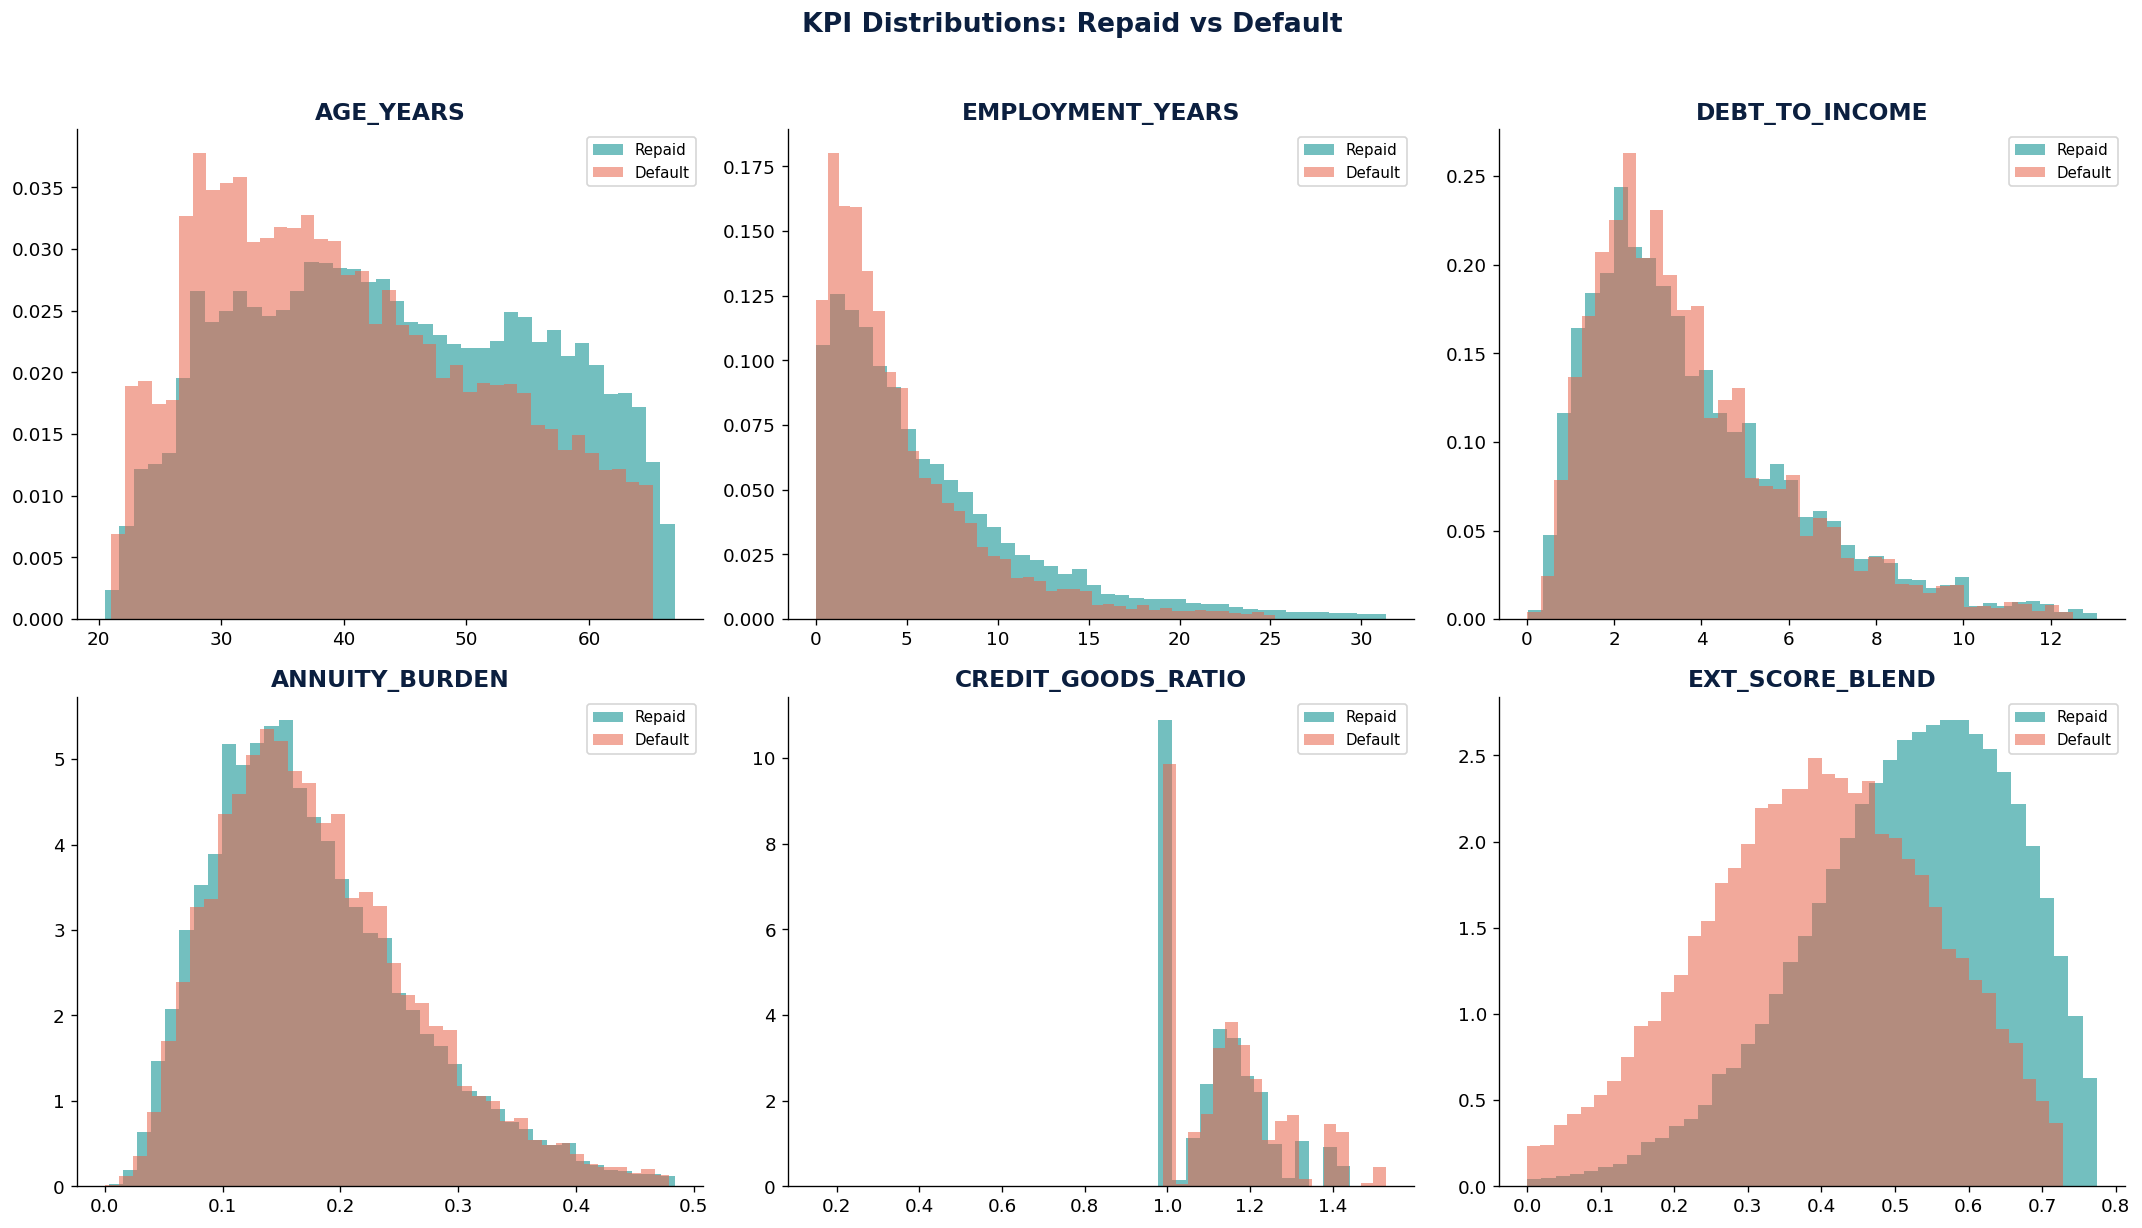

In [29]:
# ── KPI distributions by TARGET ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, kpi in enumerate(kpis):
    for target_val, color, label in [(0, TEAL, 'Repaid'), (1, CORAL, 'Default')]:
        subset = df[df['TARGET'] == target_val][kpi].dropna()
        # Clip outliers for visualisation
        q99 = subset.quantile(0.99)
        subset = subset[subset <= q99]
        axes[i].hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True)
    axes[i].set_title(kpi, color=NAVY, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('KPI Distributions: Repaid vs Default', fontsize=16, color=NAVY, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(90deg, #0B1F3F, #008C8C); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 11: Summary Statistics Dashboard</h2>
<p style="color: #008C8C; margin: 4px 0 0 0; font-size: 1.05em;">A comprehensive statistical profile of the dataset</p>
</div>

<div style="background: #E8EDF4; border-left: 5px solid #0B1F3F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #0B1F3F;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Build a final summary that captures the essential statistics any analyst should know before modelling.</span>
</div>

In [32]:
# ══════════════════════════════════════════════════════════════
#  DATASET SUMMARY DASHBOARD
# ══════════════════════════════════════════════════════════════

SEP  = "═" * 70
LINE = "─" * 68
PIPE = "│"

print(SEP)
print("  HOME CREDIT DEFAULT RISK — DATA SUMMARY")
print(SEP)

# Build stats list
stats = [
    ("Total Applications",        f"{app_train.shape[0]:,}"),
    ("Total Features (raw)",       f"{app_train.shape[1]}"),
    ("Default Rate",               f"{app_train['TARGET'].mean():.2%}"),
    ("Imbalance Ratio",            f"{(1 - app_train['TARGET'].mean()) / app_train['TARGET'].mean():.1f} : 1"),
    ("Numeric Features",           f"{app_train.select_dtypes(include=[np.number]).shape[1]}"),
    ("Categorical Features",       f"{app_train.select_dtypes(include=[object]).shape[1]}"),
    ("Columns with >50% Missing",  f"{(app_train.isnull().mean() > 0.5).sum()}"),
    ("Columns with Zero Missing",  f"{(app_train.isnull().sum() == 0).sum()}"),
    ("Median Income",              f"{app_train['AMT_INCOME_TOTAL'].median():,.0f}"),
    ("Median Credit Amount",       f"{app_train['AMT_CREDIT'].median():,.0f}"),
    ("Median Age (years)",         f"{(-app_train['DAYS_BIRTH'] / 365).median():.1f}"),
    ("DAYS_EMPLOYED Anomalies",    f"{(app_train['DAYS_EMPLOYED'] == 365243).sum():,}  ({(app_train['DAYS_EMPLOYED'] == 365243).mean():.1%})"),
    ("Thin-file Clients (no CB)",  f"{df['bureau_credit_count'].isna().sum():,}  ({df['bureau_credit_count'].isna().mean():.1%})"),
    ("Bureau Features Added",      f"{df.shape[1] - app_train.shape[1]}"),
    ("Auxiliary Tables",           "6"),
    ("Total Rows (all tables)",    "~56M"),
]

# Print table
top    = "┌" + LINE + "┐"
mid    = "├" + LINE + "┤"
bottom = "└" + LINE + "┘"

print(top)
header_label = "DIMENSION"
header_value = "VALUE"
print(f"{PIPE}  {header_label:<30s} {header_value:>33s} {PIPE}")
print(mid)

for label, value in stats:
    print(f"{PIPE}  {label:<30s} {value:>33s} {PIPE}")

print(bottom)

print("\n✅ Session 13 Data Exploration Complete!")
print("➡️  Next Session: Signal Extraction (Correlation, Variance Filters, PCA vs FA)")

══════════════════════════════════════════════════════════════════════
  HOME CREDIT DEFAULT RISK — DATA SUMMARY
══════════════════════════════════════════════════════════════════════
┌────────────────────────────────────────────────────────────────────┐
│  DIMENSION                                                  VALUE │
├────────────────────────────────────────────────────────────────────┤
│  Total Applications                                       307,511 │
│  Total Features (raw)                                         125 │
│  Default Rate                                               8.07% │
│  Imbalance Ratio                                         11.4 : 1 │
│  Numeric Features                                             109 │
│  Categorical Features                                          16 │
│  Columns with >50% Missing                                     41 │
│  Columns with Zero Missing                                     56 │
│  Median Income                            

<div style="background: linear-gradient(135deg, #0B1F3F 0%, #008C8C 100%); padding: 30px; border-radius: 12px; margin-top: 30px;">
<h2 style="color: white; font-family: Georgia, serif; margin: 0;">
✅ Session 13 Complete
</h2>
<p style="color: #B8953E; font-size: 1.15em; margin-top: 10px;">
You now have a comprehensive understanding of the Home Credit dataset: its structure, quality issues, 
key features, and the multi-table schema. You can articulate what each table contains, how they connect, 
and what business KPIs can be derived from the raw columns.
</p>
<p style="color: #B0D0D0; font-size: 1em; margin-top: 8px;">
<strong>Next Session Preview:</strong> In Session 14, we’ll use correlation screening, variance filters, 
and dimensionality reduction (PCA vs Factor Analysis) to identify which of these 120+ features actually 
matter for predicting default.
</p>
</div>